# LDPC + QPSK smoke tests (OPUS, JPEG spectrogram, Stage-1 indices)

This notebook loads **one raw audio file** (WAV) and runs three parallel experiments:

1. **OPUS**: encode to Ogg Opus bytes → LDPC encode → QPSK + AWGN → LDPC decode → decode with Opus → compare waveforms.
2. **JPEG spectrogram**: log-mel (DCASE-style) → grayscale JPEG `Q=30` → same channel → decode JPEG → compare spectrogram plots.
3. **Stage-1 indices**: pretrained VQ-VAE → index maps → pack to bytes (same layout as `transmit_indices.py`) → same channel → unpack → compare coarse/fine index maps.

**Dependencies:** `numpy`, `pyldpc`, `torch`, `torchaudio`, `matplotlib`, `Pillow`, `ffmpeg` on PATH (for Opus).

**Run order:** Configuration → LDPC setup → **Load audio and spectrogram (shared)** → Path 1 / 2 / 3 (any order after that).

## Setup: repository root and imports

In [20]:
from __future__ import annotations

import io
import os
import math
import shutil
import tempfile
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
import torchaudio
import torchaudio.transforms as T

import pyldpc
from pyldpc.utils import binaryproduct

# Resolve repo root (audDSR) so `src` imports work from this notebook
_here = Path.cwd().resolve()
REPO_ROOT = _here
for p in [_here, *_here.parents]:
    if (p / "src").is_dir():
        REPO_ROOT = p
        break
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from src.data.dataset import MEL_TIME_CROP
from src.utils.audio import standardize_spectrogram

print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: /home/lucash/Documents/NTUST/Research/papers/semantic-communication-networks/audDSR


## Configuration

Set `AUDIO_PATH` to a mono or stereo WAV (16 kHz preferred; other rates are resampled).  
Set `STAGE1_CKPT` for path 3 (path 1–2 only need `AUDIO_PATH`).

In [21]:
# --- edit these ---
AUDIO_PATH = Path("/mnt/ssd/LaCie/dcase2020_task2/dcase2020_task2_dev_dataset/fan/test/normal_id_00_00000000.wav")
STAGE1_CKPT = Path("/home/lucash/Documents/NTUST/Research/papers/semantic-communication-networks/audDSR/checkpoints/stage1/ToyCar+ToyConveyor+fan+pump+slider+valve/stage1_ToyCar+ToyConveyor+fan+pump+slider+valve_best.pt")

# If ffmpeg fails with missing libopenh264.so.5: micromamba install -n audio_ml openh264 -c conda-forge
# or point to system ffmpeg: FFMPEG_PATH = "/usr/bin/ffmpeg"
FFMPEG_PATH: str | None = None

OPUS_BITRATE_KBPS = 16
JPEG_QUALITY = 30
JPEG_CLIP = 4.0  # same as scripts/jpeg_sweep_evaluate.py

EBN0_DB = 5.0  # raise (e.g. 20) for fewer bit errors after LDPC
LDPC_N = 512
LDPC_DV = 2
LDPC_DC = 4
LDPC_MAXITER = 100
SEED = 0

SAMPLE_RATE = 16_000
N_FFT = 1024
HOP_LENGTH = 512
N_MELS = 128
F_MAX = 8000.0
TOP_DB = 80.0

## Shared: LDPC + QPSK + AWGN (pyldpc)

Same block-wise flow as `scripts/simulate_ldpc_qpsk.py`: bytes → bits (LSB-first) → LDPC blocks → QPSK → AWGN → soft LLR → BP decode.

In [22]:
SQRT2_INV = 1.0 / math.sqrt(2.0)


def bytes_to_bits_lsb_first(payload: bytes) -> np.ndarray:
    out = np.zeros(len(payload) * 8, dtype=np.uint8)
    k = 0
    for b in payload:
        for i in range(8):
            out[k] = (b >> i) & 1
            k += 1
    return out


def bits_to_bytes_lsb_first(bits: np.ndarray) -> bytes:
    n_bits = int(bits.size)
    n_bytes = (n_bits + 7) // 8
    out = bytearray(n_bytes)
    for i in range(n_bits):
        if int(bits[i]) == 1:
            out[i // 8] |= 1 << (i % 8)
    return bytes(out)


def qpsk_mod_gray(bits: np.ndarray) -> tuple[np.ndarray, int]:
    if bits.size % 2 != 0:
        bits = np.concatenate([bits, np.zeros(1, dtype=np.uint8)])
        pad = 1
    else:
        pad = 0
    b0 = bits[0::2]
    b1 = bits[1::2]
    i = np.where(b0 == 0, 1.0, -1.0)
    q = np.where(b1 == 0, 1.0, -1.0)
    s = (i + 1j * q) * SQRT2_INV
    return s.astype(np.complex64), pad


def awgn_qpsk(symbols: np.ndarray, ebn0_db: float, rng: np.random.Generator, code_rate: float) -> tuple[np.ndarray, float]:
    ebn0 = 10.0 ** (ebn0_db / 10.0)
    esn0 = ebn0 * 2.0 * code_rate
    noise_var = 1.0 / (2.0 * esn0)
    noise_std = math.sqrt(noise_var)
    noise = rng.normal(0.0, noise_std, size=symbols.shape) + 1j * rng.normal(0.0, noise_std, size=symbols.shape)
    return symbols + noise.astype(np.complex64), noise_var


def qpsk_soft_llr(rx: np.ndarray, noise_var: float, pad_bits: int) -> np.ndarray:
    llr_i = 2.0 * rx.real / noise_var
    llr_q = 2.0 * rx.imag / noise_var
    out = np.empty(rx.size * 2, dtype=np.float64)
    out[0::2] = llr_i
    out[1::2] = llr_q
    if pad_bits:
        out = out[:-pad_bits]
    return out


def llr_to_decode_observation(llr: np.ndarray) -> np.ndarray:
    soft = np.tanh(llr / 2.0)
    return np.clip(soft.astype(np.float64), -0.999999, 0.999999)


def ldpc_encode_block(msg_bits: np.ndarray, G: np.ndarray) -> np.ndarray:
    c = binaryproduct(G, msg_bits.astype(np.int64)) % 2
    return np.asarray(c, dtype=np.uint8).reshape(-1)


def ldpc_bytes_roundtrip(
    payload: bytes,
    H: np.ndarray,
    G: np.ndarray,
    k: int,
    n: int,
    ebn0_db: float,
    maxiter: int,
    rng: np.random.Generator,
) -> tuple[bytes, int, int]:
    """Returns (recovered_bytes, n_info_bits, n_bit_errors vs original)."""
    src_bits = bytes_to_bits_lsb_first(payload)
    src_n = int(src_bits.size)
    n_blocks = (src_n + k - 1) // k
    src_pad = n_blocks * k - src_n
    if src_pad > 0:
        src_bits = np.concatenate([src_bits, np.zeros(src_pad, dtype=np.uint8)])

    code_rate = float(k) / float(n)
    snr_decode_db = ebn0_db + 10.0 * math.log10(2.0 * code_rate)
    decoded_blocks: list[np.ndarray] = []

    for b in range(n_blocks):
        m = src_bits[b * k : (b + 1) * k]
        c = ldpc_encode_block(m, G)
        tx_sym, qpsk_pad = qpsk_mod_gray(c)
        rx_sym, noise_var = awgn_qpsk(tx_sym, ebn0_db, rng, code_rate)
        llr = qpsk_soft_llr(rx_sym, noise_var, qpsk_pad)
        y = llr_to_decode_observation(llr)
        dec_codeword = pyldpc.decode(H, y, snr_decode_db, maxiter=maxiter)
        dec_msg = pyldpc.get_message(G, dec_codeword).astype(np.uint8).reshape(-1)
        decoded_blocks.append(dec_msg)

    rx_bits = np.concatenate(decoded_blocks, axis=0)[:src_n]
    ref = bytes_to_bits_lsb_first(payload)
    bit_errors = int(np.count_nonzero(rx_bits != ref))
    return bits_to_bytes_lsb_first(rx_bits), src_n, bit_errors


rng = np.random.default_rng(SEED)
H, G = pyldpc.make_ldpc(LDPC_N, LDPC_DV, LDPC_DC, systematic=True, sparse=True, seed=SEED)
n_ldpc = int(G.shape[0])
k_ldpc = int(G.shape[1])
print(f"LDPC: n={n_ldpc}, k={k_ldpc}, rate={k_ldpc / n_ldpc:.4f}")

LDPC: n=512, k=257, rate=0.5020


## Load audio and spectrogram (shared)

Run this before paths 1–3. Defines `wav_in` (16 kHz, mono) and `spec` (standardized log-mel, cropped/padded like `DCASE2020Task2TestDataset`).

In [23]:
if not Path(AUDIO_PATH).is_file():
    raise FileNotFoundError(f"AUDIO_PATH not found: {AUDIO_PATH}")

wav_in, sr_in = torchaudio.load(str(AUDIO_PATH))
if sr_in != SAMPLE_RATE:
    wav_in = torchaudio.functional.resample(wav_in, sr_in, SAMPLE_RATE)
if wav_in.shape[0] > 1:
    wav_in = wav_in.mean(0, keepdim=True)

mel_tf = T.MelSpectrogram(
    sample_rate=SAMPLE_RATE,
    n_fft=N_FFT,
    hop_length=HOP_LENGTH,
    n_mels=N_MELS,
    f_min=0.0,
    f_max=F_MAX,
)
to_db = T.AmplitudeToDB(top_db=TOP_DB)

with torch.no_grad():
    mel = mel_tf(wav_in)
    log_mel = to_db(mel).float()
    spec = standardize_spectrogram(log_mel)
    spec = spec[..., :MEL_TIME_CROP]
    target_T = ((MEL_TIME_CROP + 15) // 16) * 16
    Tcur = spec.shape[-1]
    if Tcur < target_T:
        spec = F.pad(spec, (0, target_T - Tcur), mode="constant", value=0.0)

print(f"wav_in: {tuple(wav_in.shape)} @ {SAMPLE_RATE} Hz | spec: {tuple(spec.shape)}")

wav_in: (1, 160000) @ 16000 Hz | spec: (1, 128, 320)


## Path 1: OPUS → LDPC channel → Opus decode

Compares original PCM vs received PCM (time-domain overlay and difference).

**Troubleshooting:** If conda/micromamba `ffmpeg` fails with `libopenh264.so.5`, the notebook probes `/usr/bin/ffmpeg` next. You can also `micromamba install -n audio_ml openh264 -c conda-forge` or set `FFMPEG_PATH` in the config cell / environment.

Using ffmpeg: /usr/bin/ffmpeg


/home/lucash/micromamba/envs/audio_ml/lib/python3.11/site-packages/pyldpc/decoder.py:62: UserWarning: Decoding stopped before convergence. You may want
                       to increase maxiter
  warnings.warn("""Decoding stopped before convergence. You may want


Opus payload: 17566 bytes | post-LDPC BER: 4.411932e-04 (62/140528)


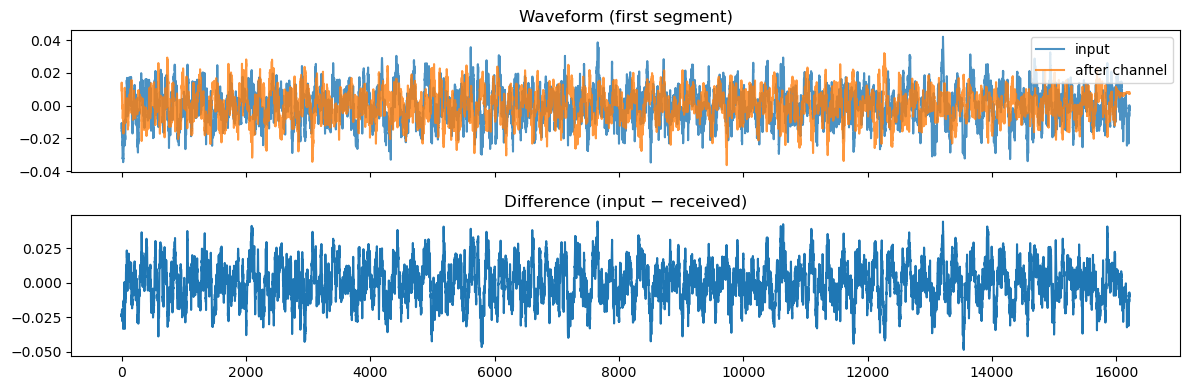

RMSE (aligned): 0.014082


In [24]:
def _resolve_ffmpeg() -> str:
    """Pick a ffmpeg binary that actually runs (conda ffmpeg often breaks without openh264)."""
    candidates: list[str] = []
    env_bin = os.environ.get("FFMPEG_PATH", "").strip()
    if env_bin:
        candidates.append(env_bin)
    cfg_ff = globals().get("FFMPEG_PATH")
    if cfg_ff:
        candidates.append(str(cfg_ff))
    w = shutil.which("ffmpeg")
    if w:
        candidates.append(w)
    for sys_path in ("/usr/bin/ffmpeg", "/bin/ffmpeg", "/usr/local/bin/ffmpeg"):
        candidates.append(sys_path)
    seen: set[str] = set()
    for c in candidates:
        if not c or c in seen:
            continue
        seen.add(c)
        if not Path(c).is_file():
            continue
        try:
            subprocess.run(
                [c, "-version"],
                capture_output=True,
                check=True,
                timeout=10,
            )
            return c
        except (OSError, subprocess.CalledProcessError, subprocess.TimeoutExpired):
            continue
    raise RuntimeError(
        "No working ffmpeg found for Opus. Fix: (1) micromamba install -n audio_ml openh264 -c conda-forge, "
        "or (2) set FFMPEG_PATH = '/usr/bin/ffmpeg' in the config cell or export FFMPEG_PATH."
    )


def wav_to_opus_bytes(wav_path: Path, bitrate_kbps: int, ffmpeg: str) -> bytes:
    with subprocess.Popen(
        [
            ffmpeg,
            "-hide_banner",
            "-loglevel",
            "error",
            "-i",
            str(wav_path),
            "-c:a",
            "libopus",
            "-b:a",
            f"{int(bitrate_kbps)}k",
            "-f",
            "opus",
            "-",
        ],
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    ) as p:
        out, err = p.communicate()
        if p.returncode != 0:
            raise RuntimeError(f"ffmpeg opus encode failed: {err.decode()}")
        return out


def opus_bytes_to_wav_tensor(opus_blob: bytes, ffmpeg: str) -> tuple[torch.Tensor, int]:
    with subprocess.Popen(
        [
            ffmpeg,
            "-hide_banner",
            "-loglevel",
            "error",
            "-i",
            "pipe:0",
            "-f",
            "wav",
            "-acodec",
            "pcm_s16le",
            "-",
        ],
        stdin=subprocess.PIPE,
        stdout=subprocess.PIPE,
        stderr=subprocess.PIPE,
    ) as p:
        out, err = p.communicate(input=opus_blob)
        if p.returncode != 0:
            raise RuntimeError(f"ffmpeg opus decode failed: {err.decode()}")
    wav, sr = torchaudio.load(io.BytesIO(out))
    return wav, int(sr)


ffmpeg = _resolve_ffmpeg()
print("Using ffmpeg:", ffmpeg)
with tempfile.NamedTemporaryFile(suffix=".wav", delete=False) as tf:
    tmp_wav = Path(tf.name)
try:
    torchaudio.save(str(tmp_wav), wav_in.cpu(), SAMPLE_RATE)
    opus_blob = wav_to_opus_bytes(tmp_wav, OPUS_BITRATE_KBPS, ffmpeg)
finally:
    tmp_wav.unlink(missing_ok=True)
rx_bytes, n_bits_opus, n_err_opus = ldpc_bytes_roundtrip(
    opus_blob, H, G, k_ldpc, n_ldpc, EBN0_DB, LDPC_MAXITER, rng
)
ber_opus = n_err_opus / max(n_bits_opus, 1)
print(f"Opus payload: {len(opus_blob)} bytes | post-LDPC BER: {ber_opus:.6e} ({n_err_opus}/{n_bits_opus})")

try:
    wav_rx, sr_rx = opus_bytes_to_wav_tensor(rx_bytes, ffmpeg)
except RuntimeError as e:
    print("Opus decode after channel failed (likely bit errors).", e)
    wav_rx = None

if wav_rx is not None:
    if sr_rx != SAMPLE_RATE:
        wav_rx = torchaudio.functional.resample(wav_rx, sr_rx, SAMPLE_RATE)
    if wav_rx.shape[0] > 1:
        wav_rx = wav_rx.mean(0, keepdim=True)
    L = min(wav_in.shape[-1], wav_rx.shape[-1])
    wi = wav_in[0, :L].numpy()
    wr = wav_rx[0, :L].numpy()
    fig, ax = plt.subplots(2, 1, figsize=(12, 4), sharex=True)
    ax[0].plot(wi, alpha=0.8, label="input")
    ax[0].plot(wr, alpha=0.8, label="after channel")
    ax[0].legend()
    ax[0].set_title("Waveform (first segment)")
    ax[1].plot(wi - wr)
    ax[1].set_title("Difference (input − received)")
    plt.tight_layout()
    plt.show()
    print(f"RMSE (aligned): {float(np.sqrt(np.mean((wi - wr) ** 2))):.6f}")

## Path 2: Log-mel spectrogram → grayscale JPEG (Q=30) → channel → compare

Uses the same per-clip standardization and time crop as `DCASE2020Task2TestDataset`, then the same uint8 mapping as `jpeg_sweep_evaluate.py`.

JPEG payload: 3248 bytes | post-LDPC BER: 3.078818e-04 (8/25984)


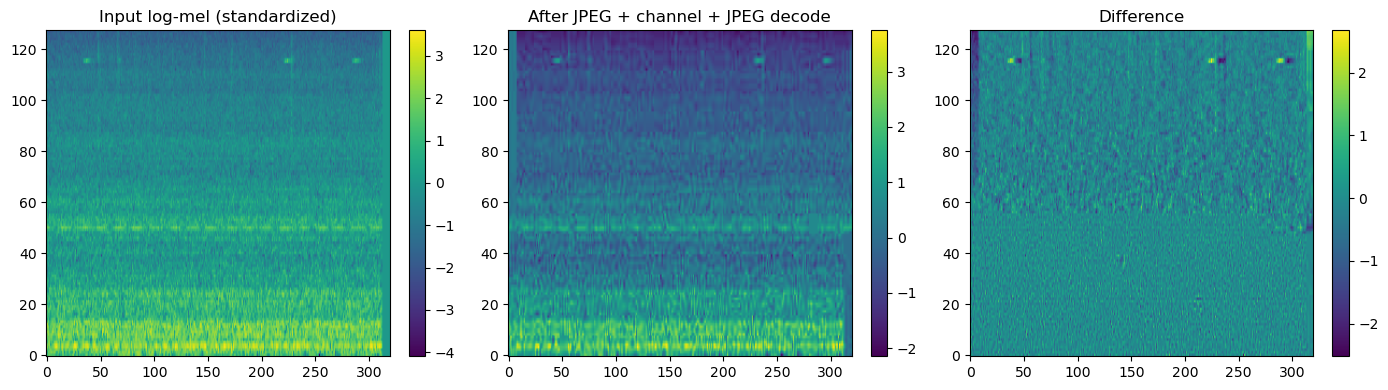

MSE (spectrogram domain): 0.192878


In [25]:
from PIL import Image

# Uses `spec` from the shared load cell (same preprocessing as DCASE test mel pipeline).
c = float(JPEG_CLIP)
x2 = spec.detach().cpu().float().clamp(-c, c)
x01 = (x2 + c) / (2.0 * c)
img_u8 = (x01.squeeze(0).numpy() * 255.0).round().astype(np.uint8)
img = Image.fromarray(img_u8, mode="L")
buf = io.BytesIO()
img.save(buf, format="JPEG", quality=int(JPEG_QUALITY), optimize=True, progressive=False, subsampling=0)
jpeg_bytes = buf.getvalue()

rx_jpeg, n_bits_j, n_err_j = ldpc_bytes_roundtrip(
    jpeg_bytes, H, G, k_ldpc, n_ldpc, EBN0_DB, LDPC_MAXITER, rng
)
print(
    f"JPEG payload: {len(jpeg_bytes)} bytes | post-LDPC BER: {n_err_j / max(n_bits_j,1):.6e} ({n_err_j}/{n_bits_j})"
)

img_rx = Image.open(io.BytesIO(rx_jpeg)).convert("L")
arr_rx = np.asarray(img_rx).astype(np.float32) / 255.0
x_rec = (arr_rx * (2.0 * c) - c).astype(np.float32)
spec_rx = torch.from_numpy(x_rec).unsqueeze(0)

orig = spec.squeeze(0).numpy()
rec = spec_rx.squeeze(0).numpy()
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
im0 = ax[0].imshow(orig, aspect="auto", origin="lower")
ax[0].set_title("Input log-mel (standardized)")
plt.colorbar(im0, ax=ax[0], fraction=0.046)
im1 = ax[1].imshow(rec, aspect="auto", origin="lower")
ax[1].set_title("After JPEG + channel + JPEG decode")
plt.colorbar(im1, ax=ax[1], fraction=0.046)
im2 = ax[2].imshow(orig - rec, aspect="auto", origin="lower")
ax[2].set_title("Difference")
plt.colorbar(im2, ax=ax[2], fraction=0.046)
plt.tight_layout()
plt.show()
print(f"MSE (spectrogram domain): {float(np.mean((orig - rec) ** 2)):.6f}")

## Path 3: Stage-1 VQ-VAE index maps → pack → channel → unpack → compare

Packing matches `src.utils.bitstream.pack_indices_to_frame` / `unpack_frame_to_indices` (LSB-first per index).  
Set `STAGE1_CKPT` to a valid Stage-1 checkpoint; spectrogram preprocessing matches path 2 so shapes align with training.

Latent grid sizes `(H_coarse, W_coarse, H_fine, W_fine)` are taken from `encode_to_indices` outputs, **not** from `n_mels//8` heuristics (those can disagree with the actual encoder strides).

In [ ]:
from src.models.vq_vae.autoencoders import VQ_VAE_2Layer
from src.utils.bitstream import frame_size_bytes, pack_indices_to_frame, unpack_frame_to_indices
from src.utils.checkpoint_compat import migrate_vq_vae_state_dict

ckpt_path = Path(STAGE1_CKPT)
if not ckpt_path.is_file():
    raise FileNotFoundError(f"STAGE1_CKPT not found: {ckpt_path}")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt = torch.load(ckpt_path, map_location="cpu", weights_only=True)

num_embeddings_coarse = ckpt.get("num_embeddings_coarse", ckpt.get("num_embeddings_top"))
num_embeddings_fine = ckpt.get("num_embeddings_fine", ckpt.get("num_embeddings_bot"))
embedding_dim = ckpt.get("embedding_dim")
if embedding_dim is None:
    embedding_dim = (ckpt["embedding_dim_coarse"], ckpt["embedding_dim_fine"])
hidden_channels = ckpt.get("hidden_channels")
if hidden_channels is None:
    hidden_channels = (ckpt["hidden_channels_coarse"], ckpt["hidden_channels_fine"])
num_residual_layers = ckpt.get("num_residual_layers", 2)

vq_vae = VQ_VAE_2Layer(
    hidden_channels=hidden_channels,
    num_residual_layers=num_residual_layers,
    num_embeddings=(num_embeddings_coarse, num_embeddings_fine),
    embedding_dim=embedding_dim,
    commitment_cost=0.25,
    decay=0.99,
)
state = dict(ckpt["model_state_dict"])
migrate_vq_vae_state_dict(state)
vq_vae.load_state_dict(state)
vq_vae = vq_vae.to(device).eval()

bits_coarse = int(math.log2(num_embeddings_coarse))
bits_fine = int(math.log2(num_embeddings_fine))

with torch.no_grad():
    x = spec.unsqueeze(0).to(device)
    ic0, if0 = vq_vae.encode_to_indices(x)

# Grid sizes must match the encoder (heuristics n_mels//8, T//16 can be wrong).
_, H_coarse, W_coarse = ic0.shape
_, H_fine, W_fine = if0.shape

frame = pack_indices_to_frame(ic0, if0, bits_coarse=bits_coarse, bits_fine=bits_fine)
expected_sz = frame_size_bytes(H_coarse, W_coarse, H_fine, W_fine, bits_coarse, bits_fine)
assert len(frame) == expected_sz, (len(frame), expected_sz, H_coarse, W_coarse, H_fine, W_fine)
rx_frame, n_bits_idx, n_err_idx = ldpc_bytes_roundtrip(
    frame, H, G, k_ldpc, n_ldpc, EBN0_DB, LDPC_MAXITER, rng
)
print(
    f"Index frame: {len(frame)} bytes | post-LDPC BER: {n_err_idx / max(n_bits_idx,1):.6e} ({n_err_idx}/{n_bits_idx})"
)

ic1, if1 = unpack_frame_to_indices(
    rx_frame,
    H_coarse,
    W_coarse,
    H_fine,
    W_fine,
    bits_coarse=bits_coarse,
    bits_fine=bits_fine,
    device=device,
)

ic0c = ic0.squeeze(0).cpu().long().numpy()
if0c = if0.squeeze(0).cpu().long().numpy()
ic1c = ic1.squeeze(0).cpu().long().numpy()
if1c = if1.squeeze(0).cpu().long().numpy()

n_mismatch_c = int(np.sum(ic0c != ic1c))
n_mismatch_f = int(np.sum(if0c != if1c))
print(f"Coarse index mismatches: {n_mismatch_c} / {ic0c.size}")
print(f"Fine index mismatches:   {n_mismatch_f} / {if0c.size}")

fig, ax = plt.subplots(2, 3, figsize=(12, 6))
ax[0, 0].imshow(ic0c, aspect="auto", origin="lower")
ax[0, 0].set_title("Coarse (tx)")
ax[0, 1].imshow(ic1c, aspect="auto", origin="lower")
ax[0, 1].set_title("Coarse (rx)")
ax[0, 2].imshow((ic0c != ic1c).astype(float), aspect="auto", origin="lower", vmin=0, vmax=1)
ax[0, 2].set_title("Coarse mismatch")
ax[1, 0].imshow(if0c, aspect="auto", origin="lower")
ax[1, 0].set_title("Fine (tx)")
ax[1, 1].imshow(if1c, aspect="auto", origin="lower")
ax[1, 1].set_title("Fine (rx)")
ax[1, 2].imshow((if0c != if1c).astype(float), aspect="auto", origin="lower", vmin=0, vmax=1)
ax[1, 2].set_title("Fine mismatch")
plt.tight_layout()
plt.show()